# Asteria EOD hedge tracking POC

Sprint 1 establishes the data and validation foundation for replaying the Asteria portfolio and its NIFTY vertical put spread. Calculation and performance cells are intentionally deferred to Sprint 2.

In [ ]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import HTML, display

search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
ROOT = next(
    (path for path in search_roots if (path / "src" / "quant_hedge_desk").is_dir()),
    None,
)

assert ROOT is not None, 'Could not locate repository root containing src/quant_hedge_desk.'
src_path = str(ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from quant_hedge_desk.data.loaders import load_portfolio_csv, load_yaml_mapping
from quant_hedge_desk.domain.enums import OptionStyle
from quant_hedge_desk.domain.models.derivative_legs import FutureLeg, VanillaOptionLeg
from quant_hedge_desk.hedge_design.candidate_generator import HedgeCandidate

## Inputs and assumptions

> **Interpretation:** Portfolio holdings are static. Candidate quantities and multipliers are used as configured. Volatility will be calibrated at inception and then held constant. Option marks will be analytical rather than observed settlement prices. Results will be reconstructed performance, not actual client P&L.

In [40]:
settings = {
    'inception_date': '2026-01-30',
    'end_date': '2026-07-30',
    'day_count': 365,
    'volatility_lower_bound': 0.0001,
    'volatility_upper_bound': 5.0,
    'calibration_tolerance': 1e-8,
    'calibration_iterations': 200,
}
display(pd.Series(settings, name='POC setting').to_frame())

,POC setting
inception_date,2026-01-30
end_date,2026-07-30
day_count,365
volatility_lower_bound,0.0001
volatility_upper_bound,5.0
calibration_tolerance,0.0
calibration_iterations,200


In [41]:
paths = {
    'portfolio': ROOT / 'cases/asteria_capital/portfolio.csv',
    'candidate': ROOT / 'cases/asteria_capital/candidate_02_nifty_vertical_put_spread.yaml',
    'pricing_snapshot': ROOT / 'data/market/pricing_snapshot_2026-01-30.yaml',
    'market_prices': ROOT / 'data/market/eod_prices_poc_2026-01-30_2026-07-30.csv',
    'market_manifest': ROOT / 'data/market/eod_prices_poc_2026-01-30_2026-07-30.manifest.json',
}
missing_files = [str(path.relative_to(ROOT)) for path in paths.values() if not path.is_file()]
assert not missing_files, f'Sprint 1 validation failed: missing input files: {missing_files}'

portfolio = load_portfolio_csv(paths['portfolio'], supplied_total_market_value='5000000000')
candidate = HedgeCandidate.from_mapping(load_yaml_mapping(paths['candidate']))
pricing_snapshot = load_yaml_mapping(paths['pricing_snapshot'])
market_manifest = json.loads(paths['market_manifest'].read_text(encoding='utf-8'))
market_prices = pd.read_csv(paths['market_prices'], parse_dates=['date'])
for column in ['adjusted_close', 'close', 'volume']:
    market_prices[column] = pd.to_numeric(market_prices[column], errors='coerce')
market_prices['symbol'] = market_prices['symbol'].str.strip().str.upper()
market_prices = market_prices.sort_values(['date', 'symbol'], ignore_index=True)

In [42]:
portfolio_table = pd.DataFrame([
    {
        'symbol': holding.symbol,
        'as_of_date': pd.Timestamp(holding.as_of_date),
        'quantity': float(holding.quantity),
        'initial_price': float(holding.price),
        'initial_market_value': float(holding.market_value),
        'portfolio_weight': float(holding.portfolio_weight),
        'sector': holding.sector,
    }
    for holding in portfolio.holdings
])

candidate_legs_table = pd.DataFrame([
    {
        'underlying': leg.underlying.value,
        'instrument_type': leg.instrument_type.value,
        'direction': leg.direction.value,
        'option_type': leg.option_type.value if isinstance(leg, VanillaOptionLeg) else None,
        'option_style': leg.option_style.value if isinstance(leg, VanillaOptionLeg) else None,
        'strike_or_level': float(leg.strike_or_level),
        'expiry': pd.Timestamp(leg.expiry),
        'quantity': leg.quantity,
        'contract_multiplier': float(leg.contract_multiplier),
        'premium': float(leg.premium) if isinstance(leg, VanillaOptionLeg) else None,
        'quote_timestamp': pd.Timestamp(leg.quote_timestamp),
    }
    for leg in candidate.legs
])

interpolation = pricing_snapshot.get('indicative_interpolation', {})
spots = pricing_snapshot.get('observed_market', {}).get('spots', {})
forwards = interpolation.get('forwards', {})
pricing_assumptions_table = pd.DataFrame([
    {
        'underlying': symbol,
        'inception_spot': float(spots[symbol]),
        'inception_forward': float(forwards[symbol]),
        'interpolated_tbill_rate': str(interpolation.get('interpolated_tbill_yield', '')),
        'valuation_timestamp': pricing_snapshot.get('valuation_timestamp'),
    }
    for symbol in sorted(set(spots) | set(forwards))
    if symbol in spots and symbol in forwards
])

display(HTML(f'<b>Portfolio:</b> {len(portfolio_table)} holdings; initial value INR {portfolio.total_market_value:,.0f}'))
display(portfolio_table.head(8))
display(HTML('<b>Configured candidate legs</b>'))
display(candidate_legs_table)
display(HTML('<b>Pricing assumptions</b>'))
display(pricing_assumptions_table)
display(HTML(f'<b>Market data:</b> {len(market_prices):,} rows from {market_prices.date.min().date()} to {market_prices.date.max().date()}'))
display(market_prices.head(8))

,symbol,as_of_date,quantity,initial_price,initial_market_value,portfolio_weight,sector
0,HDFCBANK,2026-01-30,250000.0,1600.0,400000000.0,0.080,Financials
1,ICICIBANK,2026-01-30,300000.0,1250.0,375000000.0,0.075,Financials
2,RELIANCE,2026-01-30,250000.0,1400.0,350000000.0,0.070,Energy
3,LT,2026-01-30,100000.0,3250.0,325000000.0,0.065,Industrials
4,AXISBANK,2026-01-30,250000.0,1200.0,300000000.0,0.060,Financials
5,KOTAKBANK,2026-01-30,125000.0,1800.0,225000000.0,0.045,Financials
6,SBIN,2026-01-30,200000.0,875.0,175000000.0,0.035,Financials
7,BAJFINANCE,2026-01-30,20000.0,7500.0,150000000.0,0.030,Financials


,underlying,instrument_type,direction,option_type,option_style,strike_or_level,expiry,quantity,contract_multiplier,premium,quote_timestamp
0,NIFTY,OPTION,LONG,PUT,EUROPEAN,24000.0,2026-07-30,7899,25.0,686.03,2026-01-30 15:30:00+05:30
1,NIFTY,OPTION,SHORT,PUT,EUROPEAN,22800.0,2026-07-30,7899,25.0,343.31,2026-01-30 15:30:00+05:30


,underlying,inception_spot,inception_forward,interpolated_tbill_rate,valuation_timestamp
0,BANKNIFTY,59610.45,61261.50,5.677326%,2026-01-30T15:30:00+05:30
1,NIFTY,25320.65,26083.75,5.677326%,2026-01-30T15:30:00+05:30


,date,symbol,yahoo_ticker,adjusted_close,close,volume,data_source
0,2026-01-30,ABB,ABB.NS,5491.133301,5578.500000,634906,YAHOO_FINANCE_VIA_YFINANCE
1,2026-01-30,APLAPOLLO,APLAPOLLO.NS,2045.699951,2045.699951,1175836,YAHOO_FINANCE_VIA_YFINANCE
2,2026-01-30,APOLLOHOSP,APOLLOHOSP.NS,6943.188965,6960.500000,489138,YAHOO_FINANCE_VIA_YFINANCE
3,2026-01-30,ASIANPAINT,ASIANPAINT.NS,2407.413330,2428.300049,2048843,YAHOO_FINANCE_VIA_YFINANCE
4,2026-01-30,ASTRAL,ASTRAL.NS,1474.281250,1476.599976,371018,YAHOO_FINANCE_VIA_YFINANCE
5,2026-01-30,AXISBANK,AXISBANK.NS,1369.343994,1370.400024,14758482,YAHOO_FINANCE_VIA_YFINANCE
6,2026-01-30,BAJFINANCE,BAJFINANCE.NS,924.168884,929.849976,10151379,YAHOO_FINANCE_VIA_YFINANCE
7,2026-01-30,BALKRISIND,BALKRISIND.NS,2293.820068,2305.800049,606036,YAHOO_FINANCE_VIA_YFINANCE


## Validation and replay calendar

Assertions below fail with a `Sprint 1 validation failed` message so malformed, incomplete, or inconsistent inputs are immediately identifiable. The NIFTY calendar is filtered to dates having every portfolio adjusted close and every required underlying close.

In [43]:
def require(condition, message):
    if not bool(condition):
        raise AssertionError(f'Sprint 1 validation failed: {message}')

inception = pd.Timestamp(settings['inception_date'])
end_date = pd.Timestamp(settings['end_date'])
candidate_inception = pd.Timestamp(candidate.quote_timestamp.date())
candidate_expiries = {pd.Timestamp(leg.expiry) for leg in candidate.legs}
holding_symbols = set(portfolio_table['symbol'])
underlying_symbols = {leg.underlying.value for leg in candidate.legs}
dataset_symbols = set(market_prices['symbol'])
required_dataset_symbols = holding_symbols | {'NIFTY', 'BANKNIFTY'}

require(pd.Timestamp(portfolio.as_of_date) == candidate_inception, 'portfolio and candidate inception dates do not match')
require(pd.Timestamp(portfolio.as_of_date) == inception, 'settings inception_date does not match the portfolio')
require(len(candidate_expiries) == 1, f'candidate legs must share one expiry; found {sorted(candidate_expiries)}')
candidate_expiry = next(iter(candidate_expiries))
require(candidate_expiry == end_date, 'settings end_date does not match the candidate expiry')
require(candidate_expiry >= inception, 'candidate expiry is before inception')
require(all(isinstance(leg, (VanillaOptionLeg, FutureLeg)) for leg in candidate.legs), 'candidate contains an unsupported instrument')
require(all(not isinstance(leg, VanillaOptionLeg) or leg.option_style is OptionStyle.EUROPEAN for leg in candidate.legs), 'candidate contains a non-European option')

duplicates = market_prices.duplicated(['date', 'symbol'], keep=False)
require(not duplicates.any(), f'dates are not unique per symbol; examples: {market_prices.loc[duplicates, ["date", "symbol"]].head().to_dict("records")}')
for field in ['adjusted_close', 'close']:
    valid = np.isfinite(market_prices[field]) & market_prices[field].gt(0)
    bad = market_prices.loc[~valid, ['date', 'symbol', field]].head().to_dict('records')
    require(valid.all(), f'{field} contains non-finite or non-positive prices; examples: {bad}')
missing_symbols = sorted(required_dataset_symbols - dataset_symbols)
require(not missing_symbols, f'required market symbols are absent: {missing_symbols}')
require(inception in set(market_prices['date']), 'requested inception is absent from EOD data')
require(candidate_expiry in set(market_prices['date']), 'requested expiry is absent from EOD data')
require(market_manifest.get('requested_start') == settings['inception_date'], 'manifest requested_start is inconsistent')
require(market_manifest.get('requested_end_inclusive') == settings['end_date'], 'manifest requested_end_inclusive is inconsistent')
require(market_manifest.get('symbol_count') == len(dataset_symbols), 'manifest symbol_count is inconsistent')

snapshot_date = pd.Timestamp(pricing_snapshot['valuation_timestamp']).tz_localize(None).normalize()
require(snapshot_date == inception, 'pricing snapshot valuation date does not match inception')
require(bool(interpolation.get('interpolated_tbill_yield')), 'pricing snapshot lacks the interpolated T-bill rate')
for symbol in sorted(underlying_symbols):
    require(symbol in spots, f'pricing snapshot lacks inception spot for {symbol}')
    require(symbol in forwards, f'pricing snapshot lacks inception forward for {symbol}')
    require(np.isfinite(float(spots[symbol])) and float(spots[symbol]) > 0, f'invalid inception spot for {symbol}')
    require(np.isfinite(float(forwards[symbol])) and float(forwards[symbol]) > 0, f'invalid inception forward for {symbol}')

require(len(portfolio_table) == 50, f'expected 50 holdings, found {len(portfolio_table)}')
require(abs(float(portfolio.total_market_value) - 5_000_000_000.0) < 0.01, 'initial portfolio does not reconcile to INR 5 billion')

In [44]:
in_window = market_prices['date'].between(inception, end_date)
nifty_calendar = pd.DatetimeIndex(
    market_prices.loc[in_window & market_prices['symbol'].eq('NIFTY'), 'date'].drop_duplicates().sort_values()
)
require(len(nifty_calendar) > 0, 'NIFTY replay calendar is empty')

portfolio_presence = (
    market_prices.loc[in_window & market_prices['symbol'].isin(holding_symbols)]
    .pivot(index='date', columns='symbol', values='adjusted_close')
    .reindex(index=nifty_calendar, columns=sorted(holding_symbols))
)
underlying_presence = (
    market_prices.loc[in_window & market_prices['symbol'].isin(underlying_symbols)]
    .pivot(index='date', columns='symbol', values='close')
    .reindex(index=nifty_calendar, columns=sorted(underlying_symbols))
)

excluded_records = []
for replay_date in nifty_calendar:
    missing = [f'{symbol} (adjusted_close)' for symbol in portfolio_presence.columns[portfolio_presence.loc[replay_date].isna()]]
    missing += [f'{symbol} (close)' for symbol in underlying_presence.columns[underlying_presence.loc[replay_date].isna()]]
    if missing:
        excluded_records.append({'date': replay_date, 'missing_symbols': ', '.join(missing)})
excluded_dates = pd.DataFrame(excluded_records, columns=['date', 'missing_symbols'])
excluded_index = set(excluded_dates['date']) if not excluded_dates.empty else set()
replay_calendar = pd.DatetimeIndex([date for date in nifty_calendar if date not in excluded_index])

require(inception in replay_calendar, 'inception would be excluded from the replay calendar')
require(candidate_expiry in replay_calendar, 'expiry would be excluded from the replay calendar')
require(replay_calendar.is_unique and replay_calendar.is_monotonic_increasing, 'replay calendar is not unique and increasing')

calendar_summary = pd.DataFrame({
    'metric': ['NIFTY dates', 'eligible replay dates', 'excluded dates', 'first replay date', 'last replay date'],
    'value': [len(nifty_calendar), len(replay_calendar), len(excluded_dates), replay_calendar[0].date(), replay_calendar[-1].date()],
})
display(calendar_summary)
display(HTML('<b>Excluded NIFTY dates and missing observations</b>'))
display(excluded_dates if not excluded_dates.empty else pd.DataFrame({'status': ['None; every NIFTY date is complete.']}))

,metric,value
0,NIFTY dates,122
1,eligible replay dates,122
2,excluded dates,0
3,first replay date,2026-01-30
4,last replay date,2026-07-30


,status
0,None; every NIFTY date is complete.


In [45]:
validation_summary = pd.DataFrame({
    'check': [
        'All inputs loaded through project loaders where available',
        'Portfolio and candidate inception dates match',
        'Dataset includes all 50 holdings, NIFTY, and BANKNIFTY',
        'Inception and expiry survive completeness filtering',
        'Prices are finite, positive, and unique per symbol/date',
        'Candidate instruments and pricing inputs are supported',
        'Initial portfolio reconciles to INR 5 billion',
    ],
    'status': ['PASS'] * 7,
})
display(HTML('<h3>Sprint 1 validation passed</h3>'))
display(validation_summary)

,check,status
0,All inputs loaded through project loaders wher...,PASS
1,Portfolio and candidate inception dates match,PASS
2,"Dataset includes all 50 holdings, NIFTY, and B...",PASS
3,Inception and expiry survive completeness filt...,PASS
4,"Prices are finite, positive, and unique per sy...",PASS
5,Candidate instruments and pricing inputs are s...,PASS
6,Initial portfolio reconciles to INR 5 billion,PASS


## Sprint 2 — essential calculations

The cells below reconstruct the static portfolio, calibrate each configured option premium with Black–76, mark the hedge through expiry, and reconcile gross, net, and combined P&L. Premium is the derivative cost basis; execution cost is charged once.

In [46]:
from math import erf, exp, log, sqrt

def normal_cdf(value):
    return 0.5 * (1.0 + erf(value / sqrt(2.0)))

def black76_option_value(forward, strike, time_to_expiry, volatility, discount_factor, option_type):
    require(forward > 0 and strike > 0, 'Black-76 forward and strike must be positive')
    require(time_to_expiry >= 0, 'Black-76 time to expiry cannot be negative')
    require(volatility > 0, 'Black-76 volatility must be positive')
    require(discount_factor > 0, 'Black-76 discount factor must be positive')
    option_type = str(option_type).upper()
    require(option_type in {'CALL', 'PUT'}, f'unsupported option type: {option_type}')
    if time_to_expiry == 0:
        return max(forward - strike, 0.0) if option_type == 'CALL' else max(strike - forward, 0.0)
    sigma_root_time = volatility * sqrt(time_to_expiry)
    d1 = (log(forward / strike) + 0.5 * volatility * volatility * time_to_expiry) / sigma_root_time
    d2 = d1 - sigma_root_time
    if option_type == 'CALL':
        return discount_factor * (forward * normal_cdf(d1) - strike * normal_cdf(d2))
    return discount_factor * (strike * normal_cdf(-d2) - forward * normal_cdf(-d1))

def implied_volatility(target_value, forward, strike, time_to_expiry, discount_factor, option_type, lower_bound, upper_bound, tolerance, iterations):
    lower_value = black76_option_value(forward, strike, time_to_expiry, lower_bound, discount_factor, option_type)
    upper_value = black76_option_value(forward, strike, time_to_expiry, upper_bound, discount_factor, option_type)
    require(lower_value - tolerance <= target_value <= upper_value + tolerance, f'premium {target_value} is outside bounded Black-76 values [{lower_value}, {upper_value}]')
    low, high = lower_bound, upper_bound
    for _ in range(iterations):
        midpoint = 0.5 * (low + high)
        value = black76_option_value(forward, strike, time_to_expiry, midpoint, discount_factor, option_type)
        if abs(value - target_value) <= tolerance:
            return midpoint
        if value < target_value:
            low = midpoint
        else:
            high = midpoint
    result = 0.5 * (low + high)
    require(abs(black76_option_value(forward, strike, time_to_expiry, result, discount_factor, option_type) - target_value) <= tolerance, 'implied-volatility calibration did not converge')
    return result

def option_leg_value(leg, forward, time_to_expiry, volatility, discount_factor):
    if time_to_expiry == 0:
        return max(forward - float(leg.strike_or_level), 0.0) if leg.option_type.value == 'CALL' else max(float(leg.strike_or_level) - forward, 0.0)
    return black76_option_value(forward, float(leg.strike_or_level), time_to_expiry, volatility, discount_factor, leg.option_type.value)

def future_leg_value(leg, forward, discount_factor):
    return discount_factor * (forward - float(leg.strike_or_level))

def running_drawdown(wealth):
    wealth = pd.Series(wealth, copy=False, dtype=float)
    require(np.isfinite(wealth).all() and wealth.gt(0).all(), 'wealth must be finite and positive')
    return wealth / wealth.cummax() - 1.0

In [47]:
rate = float(str(interpolation['interpolated_tbill_yield']).rstrip('%')) / 100.0
initial_time = (candidate_expiry - inception).days / settings['day_count']
inception_spots = {symbol: float(spots[symbol]) for symbol in underlying_symbols}
inception_forwards = {symbol: float(forwards[symbol]) for symbol in underlying_symbols}
carry = {symbol: log(inception_forwards[symbol] / inception_spots[symbol]) / initial_time for symbol in underlying_symbols}
initial_discount_factor = 1.0 / (1.0 + rate * initial_time)

underlying_close_panel = (
    market_prices.loc[in_window & market_prices['symbol'].isin(underlying_symbols)]
    .pivot(index='date', columns='symbol', values='close')
    .reindex(index=replay_calendar, columns=sorted(underlying_symbols))
)
calibration_forwards = {
    symbol: float(underlying_close_panel.loc[inception, symbol]) * exp(carry[symbol] * initial_time)
    for symbol in underlying_symbols
}
for symbol in sorted(underlying_symbols):
    relative_spot_difference = abs(float(underlying_close_panel.loc[inception, symbol]) / inception_spots[symbol] - 1.0)
    require(relative_spot_difference <= 1e-4, f'{symbol} inception EOD close does not reconcile to pricing snapshot spot')

model_assumptions_table = pd.DataFrame([
    {
        'underlying': symbol,
        'snapshot_spot': inception_spots[symbol],
        'eod_inception_close': float(underlying_close_panel.loc[inception, symbol]),
        'snapshot_forward': inception_forwards[symbol],
        'derived_inception_forward': calibration_forwards[symbol],
        'annualized_carry': carry[symbol],
        'simple_tbill_rate': rate,
        'initial_time_years': initial_time,
        'initial_discount_factor': initial_discount_factor,
    }
    for symbol in sorted(underlying_symbols)
])
display(HTML('<b>Derived market assumptions</b>'))
display(model_assumptions_table)

,underlying,snapshot_spot,eod_inception_close,snapshot_forward,derived_inception_forward,annualized_carry,simple_tbill_rate,initial_time_years,initial_discount_factor
0,NIFTY,25320.65,25320.65039,26083.75,26083.750402,0.059877,0.056773,0.49589,0.972618


In [48]:
calibrated_volatilities = {}
calibration_records = []
for leg_number, leg in enumerate(candidate.legs, start=1):
    if not isinstance(leg, VanillaOptionLeg):
        continue
    symbol = leg.underlying.value
    forward = calibration_forwards[symbol]
    strike = float(leg.strike_or_level)
    premium = float(leg.premium)
    option_type = leg.option_type.value
    theoretical_lower = initial_discount_factor * (max(forward - strike, 0.0) if option_type == 'CALL' else max(strike - forward, 0.0))
    theoretical_upper = initial_discount_factor * (forward if option_type == 'CALL' else strike)
    require(theoretical_lower - settings['calibration_tolerance'] <= premium <= theoretical_upper + settings['calibration_tolerance'], f'leg {leg_number} premium is outside theoretical Black-76 bounds')
    volatility = implied_volatility(
        premium, forward, strike, initial_time, initial_discount_factor, option_type,
        settings['volatility_lower_bound'], settings['volatility_upper_bound'],
        settings['calibration_tolerance'], settings['calibration_iterations'],
    )
    repriced = option_leg_value(leg, forward, initial_time, volatility, initial_discount_factor)
    difference = repriced - premium
    require(abs(difference) <= settings['calibration_tolerance'], f'leg {leg_number} repricing differs from configured premium by {difference}')
    calibrated_volatilities[leg_number] = volatility
    calibration_records.append({
        'leg_number': leg_number,
        'contract': f'{leg.direction.value} {symbol} {strike:g} {option_type} {leg.expiry.isoformat()}',
        'configured_premium': premium,
        'calibrated_volatility': volatility,
        'repriced_premium': repriced,
        'reconciliation_difference': difference,
        'lower_value_bound': theoretical_lower,
        'upper_value_bound': theoretical_upper,
    })
calibration_table = pd.DataFrame(calibration_records)
display(HTML('<b>Inception volatility calibration</b>'))
display(calibration_table)

,leg_number,contract,configured_premium,calibrated_volatility,repriced_premium,reconciliation_difference,lower_value_bound,upper_value_bound
0,1,LONG NIFTY 24000 PUT 2026-07-30,686.03,0.217288,686.03,3.126161e-09,0.0,23342.822169
1,2,SHORT NIFTY 22800 PUT 2026-07-30,343.31,0.209532,343.31,-3.439027e-11,0.0,22175.681061


In [49]:
adjusted_close_panel = (
    market_prices.loc[in_window & market_prices['symbol'].isin(holding_symbols)]
    .pivot(index='date', columns='symbol', values='adjusted_close')
    .reindex(index=replay_calendar, columns=sorted(holding_symbols))
)
initial_holding_values = portfolio_table.set_index('symbol')['initial_market_value'].reindex(adjusted_close_panel.columns)
holding_values = adjusted_close_panel.divide(adjusted_close_panel.loc[inception]).multiply(initial_holding_values, axis='columns')
portfolio_value = holding_values.sum(axis='columns')
initial_portfolio_value = float(portfolio.total_market_value)
portfolio_pnl = portfolio_value - initial_portfolio_value
unhedged_return = portfolio_pnl / initial_portfolio_value
require(abs(portfolio_value.loc[inception] - initial_portfolio_value) <= 0.01, 'reconstructed inception portfolio value does not reconcile')

portfolio_replay_table = pd.DataFrame({
    'portfolio_value': portfolio_value,
    'portfolio_pnl': portfolio_pnl,
    'unhedged_return': unhedged_return,
})
display(HTML('<b>Reconstructed portfolio — inception and expiry</b>'))
display(portfolio_replay_table.loc[[inception, candidate_expiry]])

,portfolio_value,portfolio_pnl,unhedged_return
2026-01-30,5.000000e+09,0.000000e+00,0.000000
2026-07-30,4.992825e+09,-7.174826e+06,-0.001435


In [50]:
leg_valuation_records = []
for replay_date in replay_calendar:
    days_to_expiry = max((candidate_expiry - replay_date).days, 0)
    time_to_expiry = days_to_expiry / settings['day_count']
    discount_factor = 1.0 / (1.0 + rate * time_to_expiry)
    for leg_number, leg in enumerate(candidate.legs, start=1):
        symbol = leg.underlying.value
        spot = float(underlying_close_panel.loc[replay_date, symbol])
        forward = spot if time_to_expiry == 0 else spot * exp(carry[symbol] * time_to_expiry)
        if isinstance(leg, VanillaOptionLeg):
            unit_value = option_leg_value(leg, forward, time_to_expiry, calibrated_volatilities[leg_number], discount_factor)
        else:
            unit_value = future_leg_value(leg, forward, discount_factor)
        direction_sign = 1.0 if leg.direction.value == 'LONG' else -1.0
        signed_value = unit_value * leg.quantity * float(leg.contract_multiplier) * direction_sign
        leg_valuation_records.append({
            'date': replay_date,
            'leg_number': leg_number,
            'underlying': symbol,
            'spot': spot,
            'forward': forward,
            'days_to_expiry': days_to_expiry,
            'discount_factor': discount_factor,
            'unit_value': unit_value,
            'direction_sign': direction_sign,
            'signed_leg_value': signed_value,
        })
leg_valuations = pd.DataFrame(leg_valuation_records)
hedge_value = leg_valuations.groupby('date', sort=True)['signed_leg_value'].sum().reindex(replay_calendar)

inception_hedge_value = sum(
    (1.0 if leg.direction.value == 'LONG' else -1.0)
    * (float(leg.premium) if isinstance(leg, VanillaOptionLeg) else future_leg_value(leg, calibration_forwards[leg.underlying.value], initial_discount_factor))
    * leg.quantity * float(leg.contract_multiplier)
    for leg in candidate.legs
)
execution_cost = float(candidate.estimated_execution_cost)
hedge_gross_pnl = hedge_value - inception_hedge_value
hedge_net_pnl = hedge_gross_pnl - execution_cost
combined_pnl = portfolio_pnl + hedge_net_pnl
combined_return = combined_pnl / initial_portfolio_value
hedge_benefit = combined_pnl - portfolio_pnl

unhedged_wealth = portfolio_value
hedged_wealth = initial_portfolio_value + combined_pnl
unhedged_drawdown = running_drawdown(unhedged_wealth).set_axis(replay_calendar)
hedged_drawdown = running_drawdown(hedged_wealth).set_axis(replay_calendar)

daily_results_sprint2 = pd.DataFrame({
    'portfolio_value': portfolio_value,
    'portfolio_pnl': portfolio_pnl,
    'unhedged_return': unhedged_return,
    'hedge_value': hedge_value,
    'hedge_gross_pnl': hedge_gross_pnl,
    'execution_cost': execution_cost,
    'hedge_net_pnl': hedge_net_pnl,
    'combined_pnl': combined_pnl,
    'combined_return': combined_return,
    'hedge_benefit': hedge_benefit,
    'unhedged_wealth': unhedged_wealth,
    'hedged_wealth': hedged_wealth,
    'unhedged_drawdown': unhedged_drawdown,
    'hedged_drawdown': hedged_drawdown,
})
daily_results_sprint2.index.name = 'date'
display(HTML('<b>Daily accounting — inception and expiry</b>'))
display(daily_results_sprint2.loc[[inception, candidate_expiry]])

,portfolio_value,portfolio_pnl,unhedged_return,hedge_value,hedge_gross_pnl,execution_cost,hedge_net_pnl,combined_pnl,combined_return,hedge_benefit,unhedged_wealth,hedged_wealth,unhedged_drawdown,hedged_drawdown
date,,,,,,,,,,,,,,
2026-01-30,5.000000e+09,0.000000e+00,0.000000,6.767863e+07,6.241500e-04,5000000.0,-5.000000e+06,-5.000000e+06,-0.001000,-5.000000e+06,5.000000e+09,4.995000e+09,0.0000,0.000000
2026-07-30,4.992825e+09,-7.174826e+06,-0.001435,0.000000e+00,-6.767863e+07,5000000.0,-7.267863e+07,-7.985346e+07,-0.015971,-7.267863e+07,4.992825e+09,4.920147e+09,-0.0348,-0.045494


In [51]:
money_tolerance = 0.01
numeric_results = daily_results_sprint2.select_dtypes(include=[np.number])
require(np.isfinite(numeric_results.to_numpy()).all(), 'daily results contain NaN or infinite values')
require(abs(hedge_gross_pnl.loc[inception]) <= money_tolerance, 'inception gross hedge P&L is not zero')
require(abs(hedge_net_pnl.loc[inception] + execution_cost) <= money_tolerance, 'inception net hedge P&L is not negative execution cost')
require((calibration_table['reconciliation_difference'].abs() <= settings['calibration_tolerance']).all(), 'one or more option legs do not reconcile to configured inception premium')
require(np.allclose(combined_pnl, portfolio_pnl + hedge_net_pnl, atol=money_tolerance, rtol=0), 'combined P&L identity does not reconcile')
require(np.allclose(hedge_benefit, hedge_net_pnl, atol=money_tolerance, rtol=0), 'hedge benefit does not equal net hedge P&L')
require((unhedged_drawdown <= 1e-15).all() and (hedged_drawdown <= 1e-15).all(), 'drawdown is positive')

expiry_legs = leg_valuations.loc[leg_valuations['date'].eq(candidate_expiry)].copy()
for row in expiry_legs.itertuples(index=False):
    leg = candidate.legs[row.leg_number - 1]
    if isinstance(leg, VanillaOptionLeg):
        intrinsic = max(row.spot - float(leg.strike_or_level), 0.0) if leg.option_type.value == 'CALL' else max(float(leg.strike_or_level) - row.spot, 0.0)
        require(abs(row.unit_value - intrinsic) <= money_tolerance, f'expiry mark for leg {row.leg_number} does not equal intrinsic payoff')
require(all(row.direction_sign == (-1.0 if candidate.legs[row.leg_number - 1].direction.value == 'SHORT' else 1.0) for row in expiry_legs.itertuples(index=False)), 'a leg direction sign is incorrect')
require(abs(hedge_value.loc[candidate_expiry] - expiry_legs['signed_leg_value'].sum()) <= money_tolerance, 'expiry hedge value does not equal signed terminal leg payoffs')

sprint2_acceptance = pd.DataFrame({
    'check': [
        'Inception gross hedge P&L equals zero',
        'Inception net hedge P&L equals negative execution cost',
        'Every option leg reconciles to configured premium',
        'Expiry marks equal intrinsic terminal payoff',
        'Long and short leg signs are applied correctly',
        'Daily results contain no NaN or infinite values',
        'Daily accounting identities reconcile within INR 0.01',
        'Drawdowns are never positive',
    ],
    'status': ['PASS'] * 8,
})
display(HTML('<h3>Sprint 2 validation passed</h3>'))
display(sprint2_acceptance)

,check,status
0,Inception gross hedge P&L equals zero,PASS
1,Inception net hedge P&L equals negative execut...,PASS
2,Every option leg reconciles to configured premium,PASS
3,Expiry marks equal intrinsic terminal payoff,PASS
4,Long and short leg signs are applied correctly,PASS
5,Daily results contain no NaN or infinite values,PASS
6,Daily accounting identities reconcile within I...,PASS
7,Drawdowns are never positive,PASS


,portfolio_value,portfolio_daily_pnl,portfolio_cumulative_pnl,unhedged_return,unhedged_drawdown,hedge_value,hedge_daily_pnl,hedge_gross_cumulative_pnl,hedge_net_cumulative_pnl,execution_cost,combined_pnl,combined_return,hedged_drawdown,hedge_benefit,nifty_close,days_to_expiry
date,,,,,,,,,,,,,,,,
2026-01-30,5.000000e+09,0.000000e+00,0.000000e+00,0.000000,0.000000,6.767863e+07,-5.000000e+06,6.241500e-04,-5.000000e+06,5000000.0,-5.000000e+06,-0.001000,0.000000,-5.000000e+06,25320.65039,181
2026-02-02,4.958690e+09,-4.130950e+07,-4.130950e+07,-0.008262,-0.008262,7.234970e+07,4.671064e+06,4.671064e+06,-3.289364e+05,0.0,-4.163844e+07,-0.008328,-0.007335,-3.289364e+05,25088.40039,178
2026-02-03,5.100773e+09,1.420829e+08,1.007734e+08,0.020155,0.000000,5.905757e+07,-1.329213e+07,-8.621065e+06,-1.362106e+07,0.0,8.715229e+07,0.017430,0.000000,-1.362106e+07,25727.55078,177
2026-02-04,5.114168e+09,1.339433e+07,1.141677e+08,0.022834,0.000000,5.800282e+07,-1.054751e+06,-9.675816e+06,-1.467582e+07,0.0,9.949187e+07,0.019898,0.000000,-1.467582e+07,25776.00000,176
2026-02-05,5.095886e+09,-1.828171e+07,9.588598e+07,0.019177,-0.003575,6.048132e+07,2.478506e+06,-7.197309e+06,-1.219731e+07,0.0,8.368867e+07,0.016738,-0.003099,-1.219731e+07,25642.80078,175


,review_point,date,portfolio_value,portfolio_daily_pnl,portfolio_cumulative_pnl,hedge_value,hedge_net_cumulative_pnl,combined_pnl,unhedged_drawdown,hedged_drawdown,nifty_close
0,Inception,2026-01-30,5.000000e+09,0.000000e+00,0.000000e+00,6.767863e+07,-5.000000e+06,-5.000000e+06,0.000000,0.000000,25320.65039
1,Worst portfolio day,2026-03-19,4.573279e+09,-1.595435e+08,-4.267213e+08,1.268813e+08,5.420269e+07,-3.725186e+08,-0.115906,-0.102271,23002.15039
2,Maximum unhedged drawdown,2026-03-30,4.428357e+09,-1.174182e+08,-5.716427e+08,1.491647e+08,7.648607e+07,-4.951567e+08,-0.143922,-0.126062,22331.40039
3,Expiry,2026-07-30,4.992825e+09,1.126812e+07,-7.174826e+06,0.000000e+00,-7.267863e+07,-7.985346e+07,-0.034800,-0.045494,24317.15039


,metric,value,unit
0,Initial portfolio value,5.000000e+09,INR
1,Expiry portfolio value,4.992825e+09,INR
2,Initial net premium,6.767863e+07,INR
3,Execution cost,5.000000e+06,INR
4,Unhedged expiry return,-1.434965e-03,decimal return
5,Hedged expiry return,-1.597069e-02,decimal return
6,Final hedge gross P&L,-6.767863e+07,INR
7,Final hedge net P&L,-7.267863e+07,INR
8,Hedge benefit,-7.267863e+07,INR
9,Hedge benefit,-1.453573e-02,percentage points


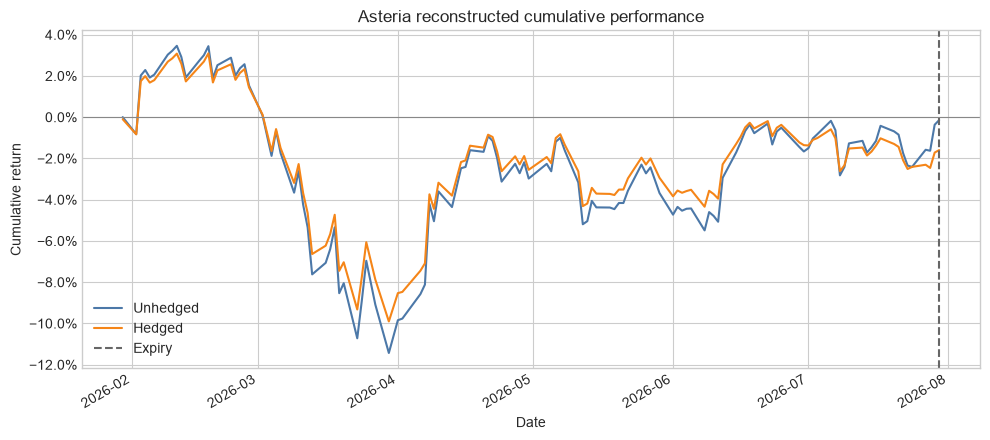

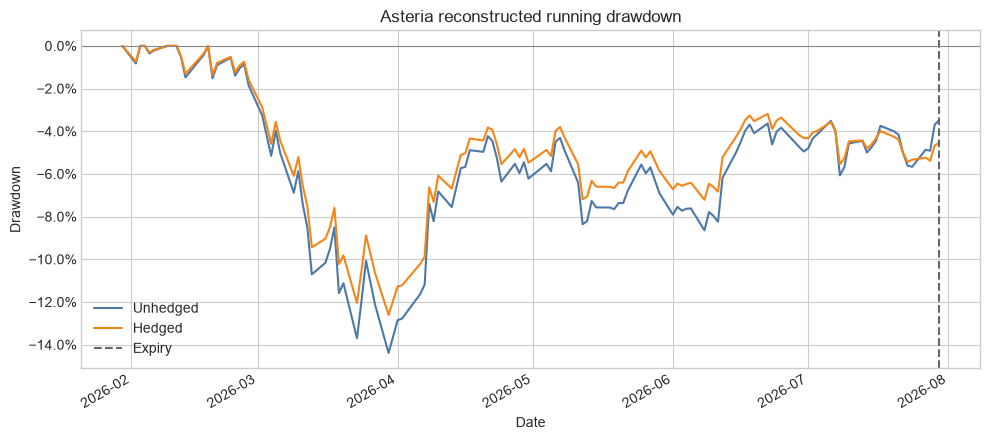

In [52]:
# Sprint 3 — aggregate results, summary, charts, export, and final assertions
portfolio_daily_pnl = portfolio_value.diff()
portfolio_daily_pnl.loc[inception] = portfolio_pnl.loc[inception]
execution_cost_series = pd.Series(0.0, index=replay_calendar)
execution_cost_series.loc[inception] = execution_cost
hedge_daily_pnl = hedge_value.diff()
hedge_daily_pnl.loc[inception] = hedge_net_pnl.loc[inception]
days_to_expiry = pd.Series([(candidate_expiry - date).days for date in replay_calendar], index=replay_calendar, dtype=int)
daily_results = pd.DataFrame({
    'portfolio_value': portfolio_value, 'portfolio_daily_pnl': portfolio_daily_pnl,
    'portfolio_cumulative_pnl': portfolio_pnl, 'unhedged_return': unhedged_return,
    'unhedged_drawdown': unhedged_drawdown, 'hedge_value': hedge_value,
    'hedge_daily_pnl': hedge_daily_pnl, 'hedge_gross_cumulative_pnl': hedge_gross_pnl,
    'hedge_net_cumulative_pnl': hedge_net_pnl, 'execution_cost': execution_cost_series,
    'combined_pnl': combined_pnl, 'combined_return': combined_return,
    'hedged_drawdown': hedged_drawdown, 'hedge_benefit': hedge_benefit,
    'nifty_close': underlying_close_panel['NIFTY'], 'days_to_expiry': days_to_expiry,
}, index=replay_calendar)
daily_results.index.name = 'date'
display(HTML(f'<h2>Sprint 3 results</h2><b>Aggregate daily table:</b> {len(daily_results)} replay dates'))
display(daily_results.head())

review_points = [('Inception', inception), ('Worst portfolio day', portfolio_daily_pnl.idxmin()), ('Maximum unhedged drawdown', unhedged_drawdown.idxmin()), ('Expiry', candidate_expiry)]
review_table = pd.concat([daily_results.loc[[date]].assign(review_point=label) for label, date in review_points]).reset_index()
review_columns = ['review_point', 'date', 'portfolio_value', 'portfolio_daily_pnl', 'portfolio_cumulative_pnl', 'hedge_value', 'hedge_net_cumulative_pnl', 'combined_pnl', 'unhedged_drawdown', 'hedged_drawdown', 'nifty_close']
display(HTML('<b>Review rows</b>'))
display(review_table[review_columns])

unhedged_max_drawdown, hedged_max_drawdown = float(unhedged_drawdown.min()), float(hedged_drawdown.min())
summary_records = [
    ('Initial portfolio value', initial_portfolio_value, 'INR'), ('Expiry portfolio value', float(portfolio_value.loc[candidate_expiry]), 'INR'),
    ('Initial net premium', inception_hedge_value, 'INR'), ('Execution cost', execution_cost, 'INR'),
    ('Unhedged expiry return', float(unhedged_return.loc[candidate_expiry]), 'decimal return'), ('Hedged expiry return', float(combined_return.loc[candidate_expiry]), 'decimal return'),
    ('Final hedge gross P&L', float(hedge_gross_pnl.loc[candidate_expiry]), 'INR'), ('Final hedge net P&L', float(hedge_net_pnl.loc[candidate_expiry]), 'INR'),
    ('Hedge benefit', float(hedge_benefit.loc[candidate_expiry]), 'INR'), ('Hedge benefit', float(combined_return.loc[candidate_expiry] - unhedged_return.loc[candidate_expiry]), 'percentage points'),
    ('Unhedged maximum drawdown', unhedged_max_drawdown, 'decimal return'), ('Hedged maximum drawdown', hedged_max_drawdown, 'decimal return'),
    ('Drawdown reduction', abs(unhedged_max_drawdown) - abs(hedged_max_drawdown), 'percentage points'),
]
summary_records += [(f'Calibrated volatility — {row.contract}', row.calibrated_volatility, 'annualized volatility') for row in calibration_table.itertuples(index=False)]
summary_table = pd.DataFrame(summary_records, columns=['metric', 'value', 'unit'])
display(HTML('<b>POC summary</b>'))
display(summary_table)

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily_results.index, daily_results['unhedged_return'], label='Unhedged', color='#4C78A8')
ax.plot(daily_results.index, daily_results['combined_return'], label='Hedged', color='#F58518')
ax.axvline(candidate_expiry, color='#666666', linestyle='--', label='Expiry'); ax.axhline(0, color='#888888', linewidth=.8)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set(title='Asteria reconstructed cumulative performance', xlabel='Date', ylabel='Cumulative return'); ax.legend(frameon=False); fig.autofmt_xdate(); fig.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily_results.index, daily_results['unhedged_drawdown'], label='Unhedged', color='#4C78A8')
ax.plot(daily_results.index, daily_results['hedged_drawdown'], label='Hedged', color='#F58518')
ax.axvline(candidate_expiry, color='#666666', linestyle='--', label='Expiry'); ax.axhline(0, color='#888888', linewidth=.8)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set(title='Asteria reconstructed running drawdown', xlabel='Date', ylabel='Drawdown'); ax.legend(frameon=False); fig.autofmt_xdate(); fig.tight_layout(); plt.show()

# Optional deterministic CSV export: change to True to write the report.
EXPORT_CSV = False
export_path = ROOT / 'reports/asteria_eod_hedge_tracking_poc.csv'
export_columns = ['date', 'portfolio_value', 'portfolio_daily_pnl', 'portfolio_cumulative_pnl', 'unhedged_return', 'unhedged_drawdown', 'hedge_value', 'hedge_daily_pnl', 'hedge_gross_cumulative_pnl', 'hedge_net_cumulative_pnl', 'execution_cost', 'combined_pnl', 'combined_return', 'hedged_drawdown', 'hedge_benefit', 'nifty_close', 'days_to_expiry']
export_frame = daily_results.reset_index(); export_frame['date'] = export_frame['date'].dt.strftime('%Y-%m-%d'); export_frame = export_frame[export_columns]
if EXPORT_CSV:
    export_frame.to_csv(export_path, index=False, float_format='%.10f', lineterminator='\n')
display(HTML(f'<b>CSV export:</b> {"written" if EXPORT_CSV else "disabled (set EXPORT_CSV = True)"}'))

# Final Sprint 3 acceptance assertions.
require(daily_results.index[0] == inception and daily_results.index[-1] == candidate_expiry, 'final date boundaries failed')
require(daily_results.index.is_unique and daily_results.index.is_monotonic_increasing, 'final dates are not increasing and unique')
require(abs(daily_results.iloc[0].portfolio_value - initial_portfolio_value) <= money_tolerance, 'initial portfolio reconciliation failed')
require((calibration_table.reconciliation_difference.abs() <= settings['calibration_tolerance']).all(), 'model marks do not reconcile')
require(np.allclose(daily_results.hedge_gross_cumulative_pnl, daily_results.hedge_value - inception_hedge_value, atol=money_tolerance, rtol=0), 'gross hedge identity failed')
require(np.allclose(daily_results.hedge_net_cumulative_pnl, daily_results.hedge_gross_cumulative_pnl - execution_cost, atol=money_tolerance, rtol=0), 'net hedge identity failed')
require(np.allclose(daily_results.hedge_daily_pnl.cumsum(), daily_results.hedge_net_cumulative_pnl, atol=money_tolerance, rtol=0), 'daily hedge identity failed')
require(np.allclose(daily_results.portfolio_daily_pnl.cumsum(), daily_results.portfolio_cumulative_pnl, atol=money_tolerance, rtol=0), 'daily portfolio identity failed')
require(np.allclose(daily_results.combined_pnl, daily_results.portfolio_cumulative_pnl + daily_results.hedge_net_cumulative_pnl, atol=money_tolerance, rtol=0), 'combined identity failed')
require(np.allclose(daily_results.hedge_benefit, daily_results.hedge_net_cumulative_pnl, atol=money_tolerance, rtol=0), 'hedge benefit identity failed')
for row in expiry_legs.itertuples(index=False):
    leg = candidate.legs[row.leg_number - 1]
    if isinstance(leg, VanillaOptionLeg):
        intrinsic = max(row.spot - float(leg.strike_or_level), 0.0) if leg.option_type.value == 'CALL' else max(float(leg.strike_or_level) - row.spot, 0.0)
        require(abs(row.unit_value - intrinsic) <= money_tolerance, f'expiry intrinsic assertion failed for leg {row.leg_number}')
require((daily_results[['unhedged_drawdown', 'hedged_drawdown']] <= 1e-15).all().all(), 'drawdown sign failed')
require(np.isfinite(daily_results.select_dtypes(include=[np.number]).to_numpy()).all(), 'numeric results are incomplete')
require(list(export_frame.columns) == export_columns, 'export ordering failed')
if EXPORT_CSV:
    exported = pd.read_csv(export_path, dtype={'date': str})
    require(exported.date.tolist() == export_frame.date.tolist(), 'exported dates differ')
    require(np.allclose(exported.drop(columns='date'), export_frame.drop(columns='date'), atol=1e-8, rtol=1e-10), 'exported values differ')
display(HTML('<h3>Sprint 3 validation passed — all assertions PASS</h3>'))